In [31]:
import os
import sys

# Move one folder up (IDPS)
project_root = os.path.abspath("..")
sys.path.append(project_root)

print(project_root)

d:\FOR VS CODE\Internship\IDPS


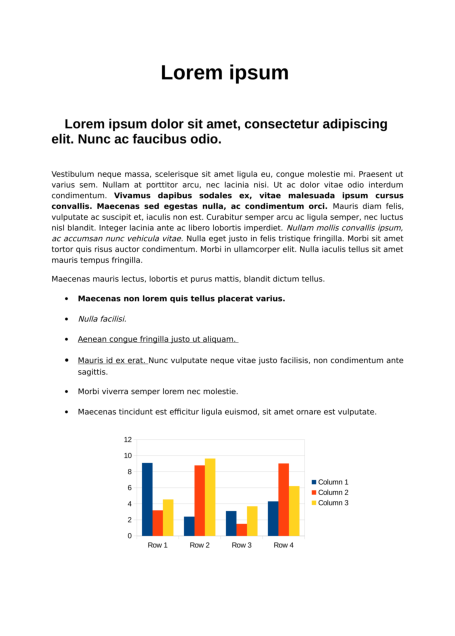

In [32]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [33]:
from processing.ocr import OCRProcessor

ocr = OCRProcessor()

image_path = "../outputs/clean_invoice.png"

results = ocr.extract_with_boxes(image_path)


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Loading EasyOCR model...


c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


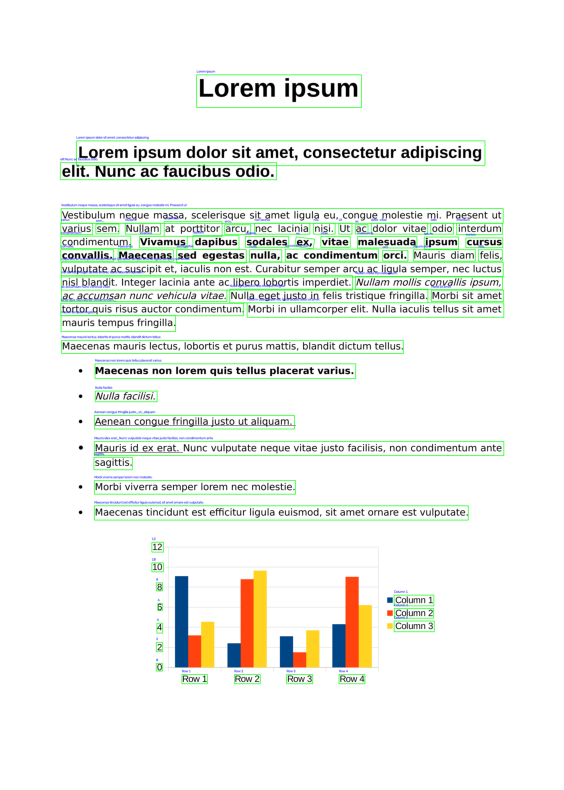

In [34]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
img = cv2.imread(image_path)

# Draw bounding boxes
for detection in results:

    box = detection[0]
    text = detection[1]
    confidence = detection[2]

    # Convert coordinates to integers
    box = [(int(x), int(y)) for x, y in box]

    # Draw the polygon
    cv2.polylines(
        img,
        [np.array(box)],
        isClosed=True,
        color=(0, 255, 0),
        thickness=2
    )

    # Display recognized text
    cv2.putText(
        img,
        text,
        (box[0][0], box[0][1] - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

# Convert BGR to RGB for matplotlib
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [35]:
cv2.imwrite("../outputs/boxed_invoice.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
print("Image saved successfully!")

Image saved successfully!
